# Import dan Prepocessing

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1yQFgpSQA5ghcXol-pdGArPRynPtnyMSM?usp=sharing

Retrieving folder contents
Processing file 1KpqsorwRBA99WCI2OUnYTuJc6je6AaIz dataset_phishing.csv
Processing file 1JxPmaxuU5k0n4JxUQQPdSxD9CQcTiPAb safealexa500.txt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1KpqsorwRBA99WCI2OUnYTuJc6je6AaIz
To: /content/Data/dataset_phishing.csv
100% 3.66M/3.66M [00:00<00:00, 54.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JxPmaxuU5k0n4JxUQQPdSxD9CQcTiPAb
To: /content/Data/safealexa500.txt
100% 4.84k/4.84k [00:00<00:00, 21.7MB/s]
Download completed


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
df = pd.read_csv('/content/Data/dataset_phishing.csv')
df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [ ]:
from urllib.parse import urlparse

with open('/content/Data/safealexa500.txt', 'r') as f:
    allow_list = [line.strip() for line in f if line.strip()]

def extract_domain(url):
    try:
        domain = urlparse(url).netloc.lower()

        if domain.startswith("www."):
            domain = domain[4:]
        return domain
    except:
        return ""

df["domain"] = df["url"].apply(extract_domain)
df["is_allow_list"] = df["domain"].apply(
    lambda d: 1 if any(d == allow or d.endswith("." + allow) for allow in allow_list) else 0
)
df.loc[df["is_allow_list"] == 1, "status"] = "legitimate"
df

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status,domain,is_allow_list
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,45,-1,0,1,1,4,legitimate,crestonwood.com,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,0,77,5767,0,0,1,2,phishing,shadetreetechnology.com,0
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,0,14,4004,5828815,0,1,0,phishing,support-appleld.com.secureupdate.duilawyeryork...,0
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,0,62,-1,107721,0,0,3,legitimate,rgipt.ac.in,0
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,224,8175,8725,0,0,6,legitimate,iracing.com,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,0,0,0,...,0,448,5396,3980,0,0,6,legitimate,fontspace.com,0
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,0,211,6728,0,0,1,0,phishing,budgetbots.com,0
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,2809,8515,8,0,1,10,legitimate,facebook.com,0
11428,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,0,0,0,...,0,85,2836,2455493,0,0,4,legitimate,mypublicdomainpictures.com,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

X = df.drop("status", axis=1)
y = df["status"]

# Encode target variable to numerical labels
le = LabelEncoder()
y = pd.Series(le.fit_transform(y), index=y.index, name='status')

In [ ]:
from sklearn.feature_selection import VarianceThreshold

constant_filter = VarianceThreshold(threshold=0)
X = X.drop(['url', 'domain'], axis=1)
constant_filter.fit(X)
X = X.loc[:, constant_filter.get_support()]

print("Setelah remove constant:", X.shape)

Setelah remove constant: (11430, 82)


In [ ]:
# HAPUS DUPLICATE FEATURES (FITUR IDENTIK)

X_T = X.T
X_no_duplicate = X_T.drop_duplicates().T
X = X_no_duplicate
print("Setelah remove duplicate:", X.shape)


Setelah remove duplicate: (11430, 82)


In [ ]:
# HAPUS QUASI-CONSTANT FEATURES

quasi_const_filter = VarianceThreshold(threshold=0.01)
quasi_const_filter.fit(X)

X = X[X.columns[quasi_const_filter.get_support()]]
print("Setelah remove quasi-constant:", X.shape)

Setelah remove quasi-constant: (11430, 66)


In [ ]:
# HAPUS HIGHLY CORRELATED FEATURES
# (korelasi > 0.85)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.85)]
X = X.drop(columns=to_drop_corr)

print("Setelah remove correlated:", X.shape)

Setelah remove correlated: (11430, 64)


In [ ]:
# MUTUAL INFORMATION GAIN

mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# Memilih fitur dengan MI > 0.22
selected_mi = mi_series[mi_series > 0.22].index
X = X[selected_mi]

print("Setelah Mutual Information:", X.shape)

Setelah Mutual Information: (11430, 6)


In [ ]:
# NORMALIZATION (MIN-MAX SCALING)

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Setelah Normalisasi:", X_scaled.shape)

Setelah Normalisasi: (11430, 6)


In [ ]:
# SPLIT TRAIN & TEST
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (8005, 6)
Validation: (1710, 6)
Test: (1715, 6)


## EDA

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   domain_age           11430 non-null  float64
 1   web_traffic          11430 non-null  float64
 2   page_rank            11430 non-null  float64
 3   google_index         11430 non-null  float64
 4   ratio_intHyperlinks  11430 non-null  float64
 5   ratio_extHyperlinks  11430 non-null  float64
dtypes: float64(6)
memory usage: 535.9 KB


In [ ]:
# Descriptive statistics
print(X.describe())

# Check for missing values
missing_values = X.isnull().sum()
print("Missing Values:\n", missing_values)


         domain_age   web_traffic     page_rank  google_index  \
count  11430.000000  1.143000e+04  11430.000000  11430.000000   
mean    4062.543745  8.567566e+05      3.185739      0.533946   
std     3107.784600  1.995606e+06      2.536955      0.498868   
min      -12.000000  0.000000e+00      0.000000      0.000000   
25%      972.250000  0.000000e+00      1.000000      0.000000   
50%     3993.000000  1.651000e+03      3.000000      1.000000   
75%     7026.750000  3.738455e+05      5.000000      1.000000   
max    12874.000000  1.076799e+07     10.000000      1.000000   

       ratio_intHyperlinks  ratio_extHyperlinks  
count         11430.000000         11430.000000  
mean              0.602457             0.276720  
std               0.376474             0.319958  
min               0.000000             0.000000  
25%               0.224991             0.000000  
50%               0.743442             0.131148  
75%               0.944767             0.474840  
max           

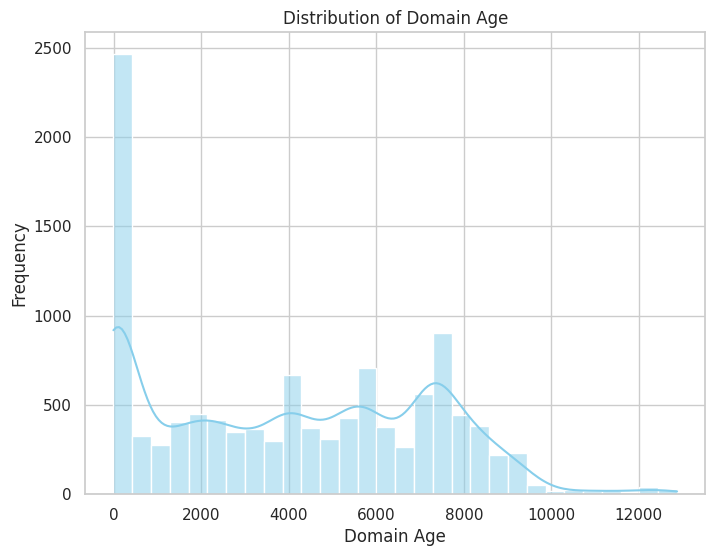

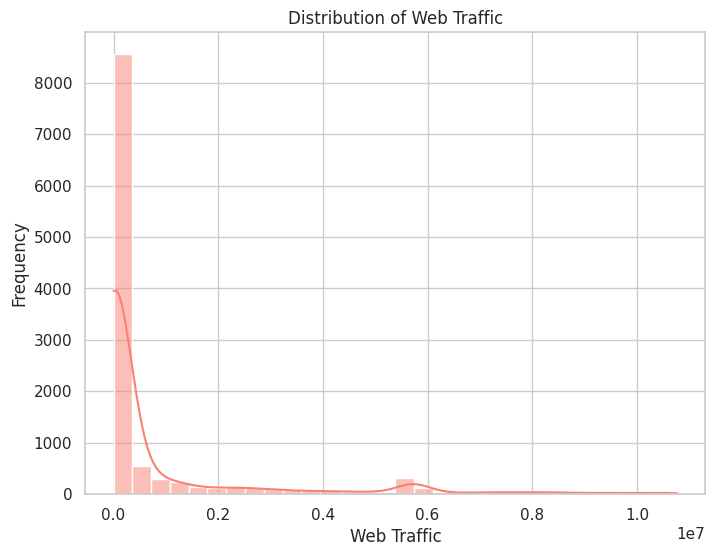

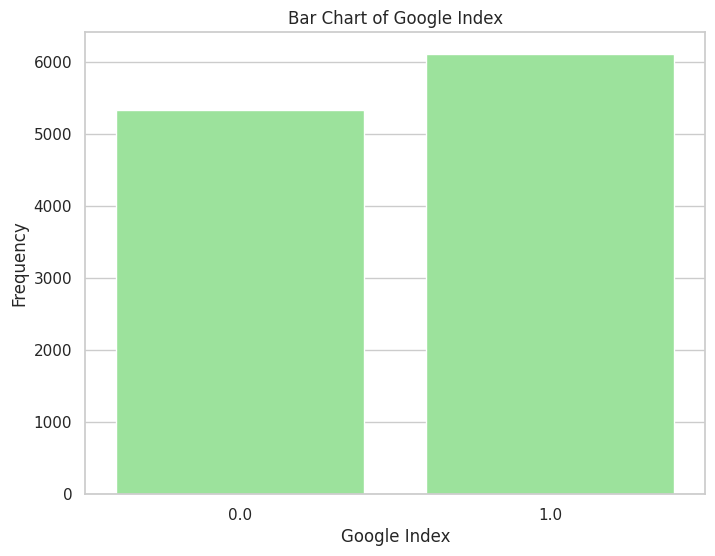

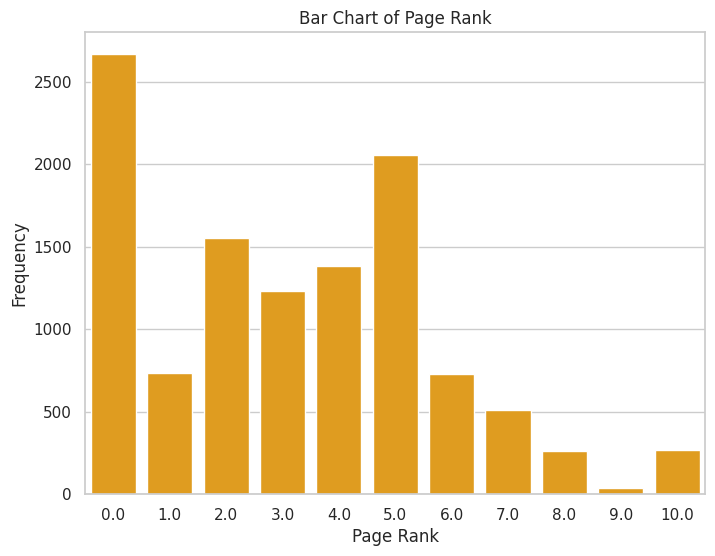

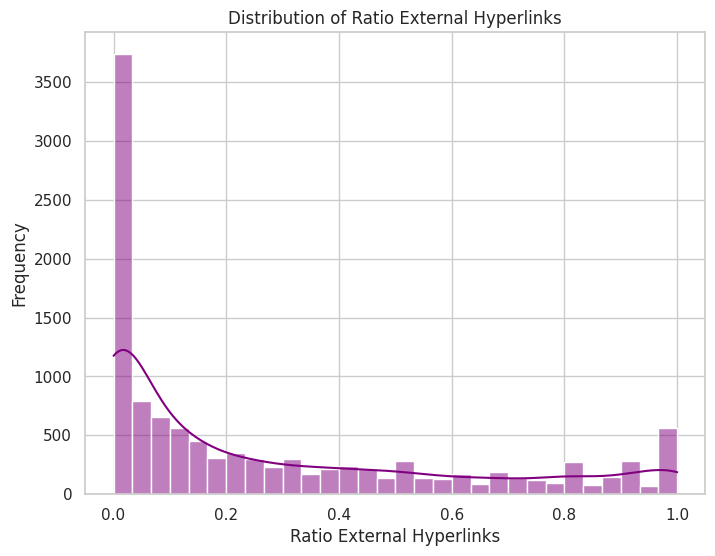

/tmp/ipython-input-1033837101.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['status'].value_counts().index, y=df['status'].value_counts().values, palette='Set2')


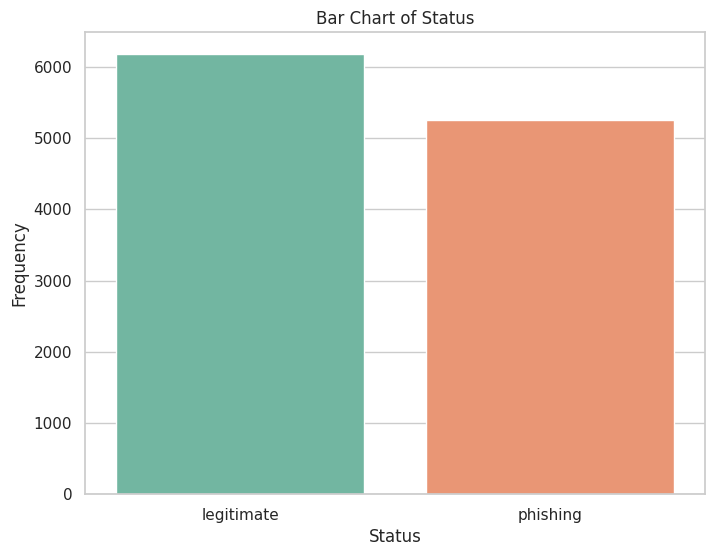

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'X' is your main DataFrame and 'y' contains a 'status' column
sns.set(style="whitegrid")

# Plot for domain_age (Histogram)
plt.figure(figsize=(8, 6))
sns.histplot(X['domain_age'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Domain Age')
plt.xlabel('Domain Age')
plt.ylabel('Frequency')
plt.show()

# Plot for web_traffic (Histogram)
plt.figure(figsize=(8, 6))
sns.histplot(X['web_traffic'], kde=True, color='salmon', bins=30)
plt.title('Distribution of Web Traffic')
plt.xlabel('Web Traffic')
plt.ylabel('Frequency')
plt.show()

# Plot for google_index (Bar Chart)
plt.figure(figsize=(8, 6))
sns.barplot(x=X['google_index'].value_counts().index, y=X['google_index'].value_counts().values, color='lightgreen')
plt.title('Bar Chart of Google Index')
plt.xlabel('Google Index')
plt.ylabel('Frequency')
plt.show()

# Plot for page_rank (Bar Chart)
plt.figure(figsize=(8, 6))
sns.barplot(x=X['page_rank'].value_counts().index, y=X['page_rank'].value_counts().values, color='orange')
plt.title('Bar Chart of Page Rank')
plt.xlabel('Page Rank')
plt.ylabel('Frequency')
plt.show()

# Plot for ratio_extHyperlinks (Histogram)
plt.figure(figsize=(8, 6))
sns.histplot(X['ratio_extHyperlinks'], kde=True, color='purple', bins=30)
plt.title('Distribution of Ratio External Hyperlinks')
plt.xlabel('Ratio External Hyperlinks')
plt.ylabel('Frequency')
plt.show()

# Plot for status (Bar Chart)
plt.figure(figsize=(8, 6))
sns.barplot(x=df['status'].value_counts().index, y=df['status'].value_counts().values, palette='Set2')
plt.title('Bar Chart of Status')
plt.xlabel('Status')
plt.ylabel('Frequency')
plt.show()

# Model

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model on training data
rf_model.fit(X_train, y_train)

# Predict on training, validation, and test sets
y_pred_train_rf = rf_model.predict(X_train)
y_pred_val_rf = rf_model.predict(X_val)
y_pred_test_rf = rf_model.predict(X_test)

=== CLASSIFICATION REPORT (TRAIN) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4328
           1       1.00      1.00      1.00      3677

    accuracy                           1.00      8005
   macro avg       1.00      1.00      1.00      8005
weighted avg       1.00      1.00      1.00      8005


=== CLASSIFICATION REPORT (VALIDATION) ===
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       924
           1       0.95      0.94      0.94       786

    accuracy                           0.95      1710
   macro avg       0.95      0.95      0.95      1710
weighted avg       0.95      0.95      0.95      1710


=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       927
           1       0.94      0.93      0.94       788

    accuracy                           0.94      1715
   macro

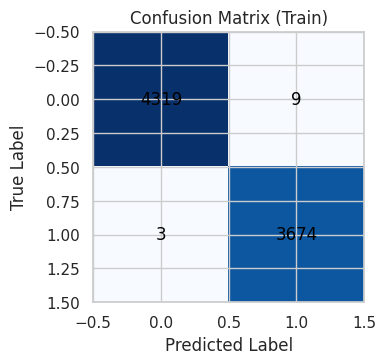

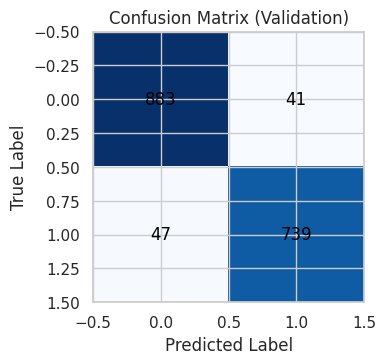

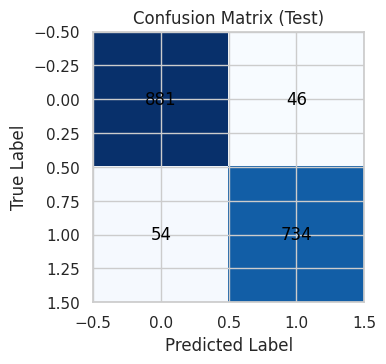

In [ ]:
# Print classification reports for each dataset
print("=== CLASSIFICATION REPORT (TRAIN) ===")
print(classification_report(y_train, y_pred_train_rf))

print("\n=== CLASSIFICATION REPORT (VALIDATION) ===")
print(classification_report(y_val, y_pred_val_rf))

print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(y_test, y_pred_test_rf))

# Function to plot confusion matrix
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4,4))
    plt.imshow(cm, cmap="Blues")

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color="black")

    plt.tight_layout()
    plt.show()

# Confusion matrices for each dataset
cm_train = confusion_matrix(y_train, y_pred_train_rf)
plot_confusion_matrix(cm_train, "Confusion Matrix (Train)")

cm_val = confusion_matrix(y_val, y_pred_val_rf)
plot_confusion_matrix(cm_val, "Confusion Matrix (Validation)")

cm_test = confusion_matrix(y_test, y_pred_test_rf)
plot_confusion_matrix(cm_test, "Confusion Matrix (Test)")

## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

dt_clf.fit(X_train, y_train)
y_pred_train_dt = dt_clf.predict(X_train)
y_pred_val_dt = dt_clf.predict(X_val)
y_pred_test_dt = dt_clf.predict(X_test)

acc_val_dt = accuracy_score(y_val, y_pred_val_dt)
acc_test_dt = accuracy_score(y_test, y_pred_test_dt)


===== DECISION TREE (Scaled) =====
Validation Accuracy : 0.9222222222222223
Test Accuracy       : 0.9154518950437318

Classification Report (Validation):
              precision    recall  f1-score   support

  legitimate       0.94      0.91      0.93       924
    phishing       0.90      0.93      0.92       786

    accuracy                           0.92      1710
   macro avg       0.92      0.92      0.92      1710
weighted avg       0.92      0.92      0.92      1710


Confusion Matrix (Validation):
[[845  79]
 [ 54 732]]

Classification Report (Test):
              precision    recall  f1-score   support

  legitimate       0.93      0.92      0.92       927
    phishing       0.90      0.91      0.91       788

    accuracy                           0.92      1715
   macro avg       0.91      0.92      0.91      1715
weighted avg       0.92      0.92      0.92      1715


Confusion Matrix (Test):
[[849  78]
 [ 67 721]]


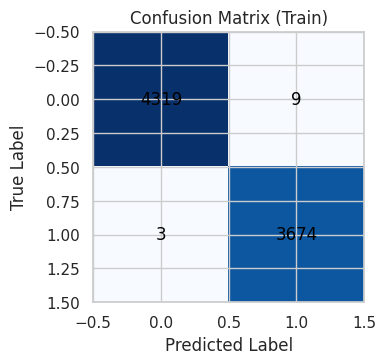

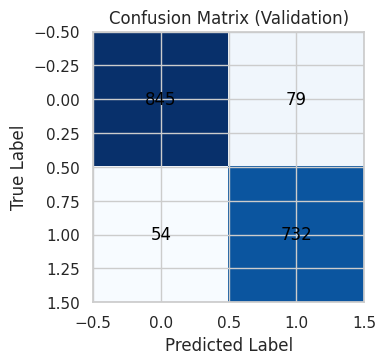

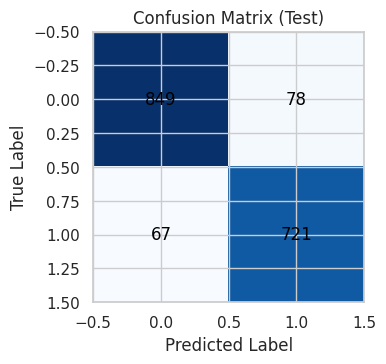

In [ ]:
print("\n===== DECISION TREE (Scaled) =====")
print("Validation Accuracy :", acc_val_dt)
print("Test Accuracy       :", acc_test_dt)

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_pred_val_dt,
                            target_names=["legitimate", "phishing"]))

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_pred_val_dt))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test_dt,
                            target_names=["legitimate", "phishing"]))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test_dt))

# Confusion matrices for each dataset
cm_train = confusion_matrix(y_train, y_pred_train_dt)
plot_confusion_matrix(cm_train, "Confusion Matrix (Train)")

cm_val = confusion_matrix(y_val, y_pred_val_dt)
plot_confusion_matrix(cm_val, "Confusion Matrix (Validation)")

cm_test = confusion_matrix(y_test, y_pred_test_dt)
plot_confusion_matrix(cm_test, "Confusion Matrix (Test)")

## XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Initialize the XGBoost model
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Fit the model on training data
xgb_model.fit(X_train, y_train)

# Predict on training, validation, and test sets
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_val_xgb = xgb_model.predict(X_val)
y_pred_test_xgb = xgb_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:02:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== CLASSIFICATION REPORT (TRAIN) ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4328
           1       0.98      0.99      0.98      3677

    accuracy                           0.99      8005
   macro avg       0.99      0.99      0.99      8005
weighted avg       0.99      0.99      0.99      8005


=== CLASSIFICATION REPORT (VALIDATION) ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       924
           1       0.94      0.94      0.94       786

    accuracy                           0.95      1710
   macro avg       0.94      0.94      0.94      1710
weighted avg       0.95      0.95      0.95      1710


=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       927
           1       0.94      0.93      0.94       788

    accuracy                           0.94      1715
   macro

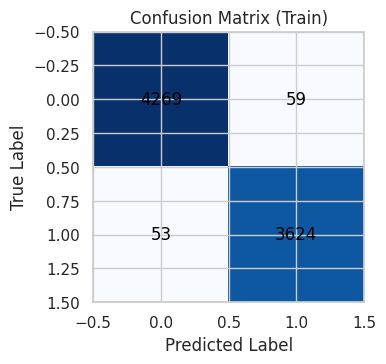

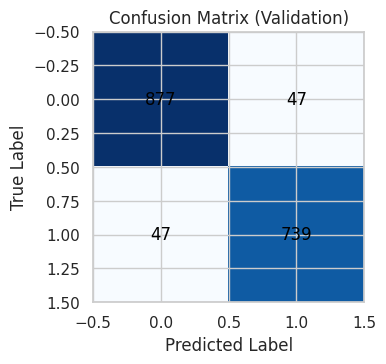

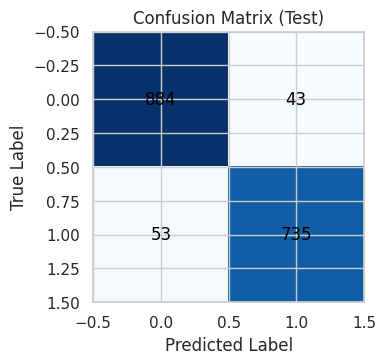

In [ ]:
# Print classification reports for each dataset
print("=== CLASSIFICATION REPORT (TRAIN) ===")
print(classification_report(y_train, y_pred_train_xgb))

print("\n=== CLASSIFICATION REPORT (VALIDATION) ===")
print(classification_report(y_val, y_pred_val_xgb))

print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(y_test, y_pred_test_xgb))

# Confusion matrices for each dataset
cm_train = confusion_matrix(y_train, y_pred_train_xgb)
plot_confusion_matrix(cm_train, "Confusion Matrix (Train)")

cm_val = confusion_matrix(y_val, y_pred_val_xgb)
plot_confusion_matrix(cm_val, "Confusion Matrix (Validation)")

cm_test = confusion_matrix(y_test, y_pred_test_xgb)
plot_confusion_matrix(cm_test, "Confusion Matrix (Test)")

## Catboost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.6 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Initialize the CatBoost model
catboost_model = CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.1, loss_function='Logloss', random_state=42, verbose=0)

# Fit the model on training data
catboost_model.fit(X_train, y_train)

# Predict on training, validation, and test sets
y_pred_train_cb = catboost_model.predict(X_train)
y_pred_val_cb = catboost_model.predict(X_val)
y_pred_test_cb = catboost_model.predict(X_test)

In [ ]:
# Print classification reports for each dataset
print("=== CLASSIFICATION REPORT (TRAIN) ===")
print(classification_report(y_train, y_pred_train_cb))

print("\n=== CLASSIFICATION REPORT (VALIDATION) ===")
print(classification_report(y_val, y_pred_val_cb))

print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(y_test, y_pred_test_cb))

=== CLASSIFICATION REPORT (TRAIN) ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4328
           1       0.99      0.99      0.99      3677

    accuracy                           0.99      8005
   macro avg       0.99      0.99      0.99      8005
weighted avg       0.99      0.99      0.99      8005


=== CLASSIFICATION REPORT (VALIDATION) ===
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       924
           1       0.95      0.94      0.94       786

    accuracy                           0.95      1710
   macro avg       0.95      0.95      0.95      1710
weighted avg       0.95      0.95      0.95      1710


=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       927
           1       0.94      0.93      0.94       788

    accuracy                           0.94      1715
   macro

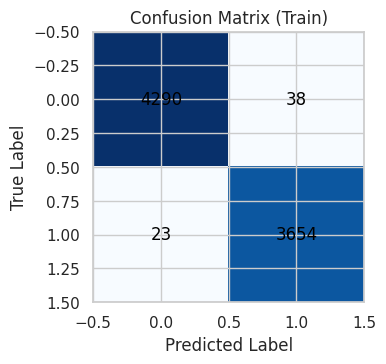

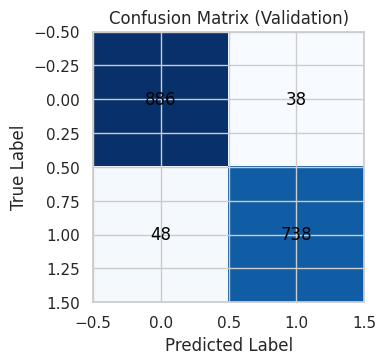

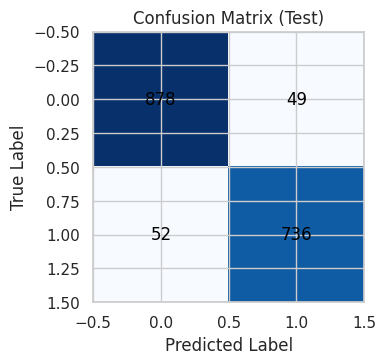

In [ ]:
# Confusion matrices for each dataset
cm_train = confusion_matrix(y_train, y_pred_train_cb)
plot_confusion_matrix(cm_train, "Confusion Matrix (Train)")

cm_val = confusion_matrix(y_val, y_pred_val_cb)
plot_confusion_matrix(cm_val, "Confusion Matrix (Validation)")

cm_test = confusion_matrix(y_test, y_pred_test_cb)
plot_confusion_matrix(cm_test, "Confusion Matrix (Test)")

## Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_train_nb = nb_model.predict(X_train)
y_pred_val_nb = nb_model.predict(X_val)
y_pred_test_nb = nb_model.predict(X_test)

=== CLASSIFICATION REPORT (TRAIN) ===
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      4328
           1       0.89      0.82      0.85      3677

    accuracy                           0.87      8005
   macro avg       0.87      0.87      0.87      8005
weighted avg       0.87      0.87      0.87      8005


=== CLASSIFICATION REPORT (VALIDATION) ===
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       924
           1       0.90      0.82      0.86       786

    accuracy                           0.88      1710
   macro avg       0.88      0.87      0.88      1710
weighted avg       0.88      0.88      0.88      1710


=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       927
           1       0.88      0.84      0.86       788

    accuracy                           0.87      1715
   macro

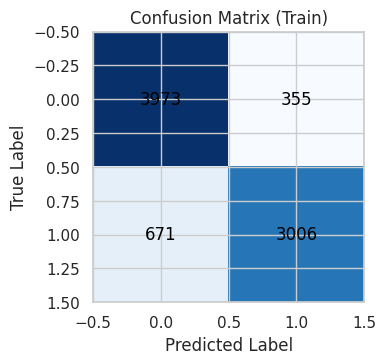

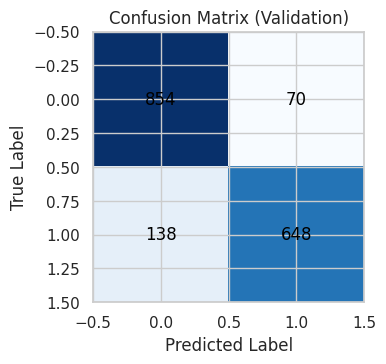

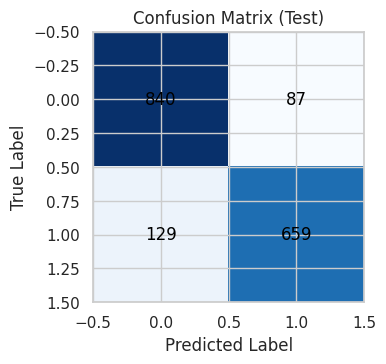

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("=== CLASSIFICATION REPORT (TRAIN) ===")
print(classification_report(y_train, y_pred_train_nb))

print("\n=== CLASSIFICATION REPORT (VALIDATION) ===")
print(classification_report(y_val, y_pred_val_nb))

print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(y_test, y_pred_test_nb))

cm_train = confusion_matrix(y_train, y_pred_train_nb)
plot_confusion_matrix(cm_train, "Confusion Matrix (Train)")

cm_val = confusion_matrix(y_val, y_pred_val_nb)
plot_confusion_matrix(cm_val, "Confusion Matrix (Validation)")

cm_test = confusion_matrix(y_test, y_pred_test_nb)
plot_confusion_matrix(cm_test, "Confusion Matrix (Test)")

## Light GBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

y_pred_train_lgbm = lgbm_model.predict(X_train)
y_pred_val_lgbm = lgbm_model.predict(X_val)
y_pred_test_lgbm = lgbm_model.predict(X_test)

[LightGBM] [Info] Number of positive: 3677, number of negative: 4328
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003994 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1033
[LightGBM] [Info] Number of data points in the train set: 8005, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.459338 -> initscore=-0.163008
[LightGBM] [Info] Start training from score -0.163008


=== CLASSIFICATION REPORT (TRAIN) ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4328
           1       0.98      0.97      0.98      3677

    accuracy                           0.98      8005
   macro avg       0.98      0.98      0.98      8005
weighted avg       0.98      0.98      0.98      8005


=== CLASSIFICATION REPORT (VALIDATION) ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       924
           1       0.94      0.94      0.94       786

    accuracy                           0.95      1710
   macro avg       0.95      0.95      0.95      1710
weighted avg       0.95      0.95      0.95      1710


=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       927
           1       0.95      0.94      0.94       788

    accuracy                           0.95      1715
   macro

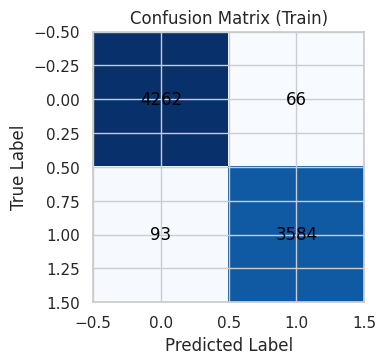

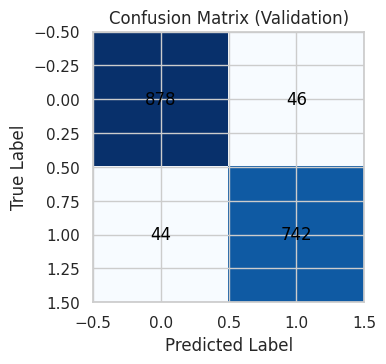

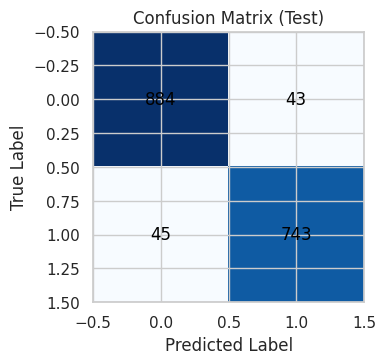

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("=== CLASSIFICATION REPORT (TRAIN) ===")
print(classification_report(y_train, y_pred_train_lgbm))

print("\n=== CLASSIFICATION REPORT (VALIDATION) ===")
print(classification_report(y_val, y_pred_val_lgbm))

print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(y_test, y_pred_test_lgbm))

cm_train = confusion_matrix(y_train, y_pred_train_lgbm)
plot_confusion_matrix(cm_train, "Confusion Matrix (Train)")

cm_val = confusion_matrix(y_val, y_pred_val_lgbm)
plot_confusion_matrix(cm_val, "Confusion Matrix (Validation)")

cm_test = confusion_matrix(y_test, y_pred_test_lgbm)
plot_confusion_matrix(cm_test, "Confusion Matrix (Test)")

## Logistic Regression

===== LOGISTIC REGRESSION - Validation =====
Validation Accuracy : 0.908187134502924

Classification Report (Validation):
              precision    recall  f1-score   support

  legitimate       0.91      0.92      0.92       924
    phishing       0.90      0.90      0.90       786

    accuracy                           0.91      1710
   macro avg       0.91      0.91      0.91      1710
weighted avg       0.91      0.91      0.91      1710

Confusion Matrix (Validation):
[[846  78]
 [ 79 707]]


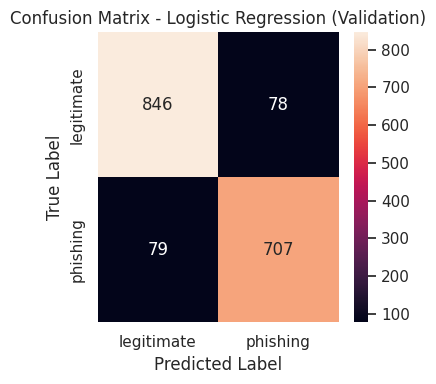


===== LOGISTIC REGRESSION - Test =====
Test Accuracy : 0.9020408163265307

Classification Report (Test):
              precision    recall  f1-score   support

  legitimate       0.92      0.90      0.91       927
    phishing       0.89      0.90      0.89       788

    accuracy                           0.90      1715
   macro avg       0.90      0.90      0.90      1715
weighted avg       0.90      0.90      0.90      1715

Confusion Matrix (Test):
[[836  91]
 [ 77 711]]


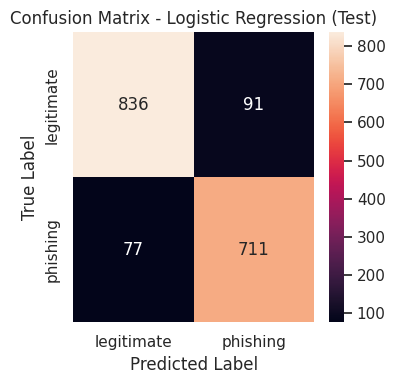

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# --- Training ---
log_reg.fit(X_train, y_train)

# --- Evaluasi (Validation) ---
y_pred_val_lr = log_reg.predict(X_val)
acc_val_log = accuracy_score(y_val, y_pred_val_lr)

#--- Evaluasi (Test) ---
y_pred_test_lr = log_reg.predict(X_test)
acc_test_log = accuracy_score(y_test, y_pred_test_lr)

print("===== LOGISTIC REGRESSION - Validation =====")
print("Validation Accuracy :", acc_val_log)
print("\nClassification Report (Validation):")
print(classification_report(
    y_val, y_pred_val_lr,
    target_names=["legitimate", "phishing"]
))
print("Confusion Matrix (Validation):")
cm_val_log = confusion_matrix(y_val, y_pred_val_lr)
print(cm_val_log)

plt.figure(figsize=(4,4))
sns.heatmap(cm_val_log,
            annot=True, fmt="d",
            xticklabels=["legitimate", "phishing"],
            yticklabels=["legitimate", "phishing"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression (Validation)")
plt.tight_layout()
plt.show()

print("\n===== LOGISTIC REGRESSION - Test =====")
print("Test Accuracy :", acc_test_log)
print("\nClassification Report (Test):")
print(classification_report(
    y_test, y_pred_test_lr,
    target_names=["legitimate", "phishing"]
))
print("Confusion Matrix (Test):")
cm_test_log = confusion_matrix(y_test, y_pred_test_lr)
print(cm_test_log)

plt.figure(figsize=(4,4))
sns.heatmap(cm_test_log,
            annot=True, fmt="d",
            xticklabels=["legitimate", "phishing"],
            yticklabels=["legitimate", "phishing"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression (Test)")
plt.tight_layout()
plt.show()

## SVM

Sedang melatih model SVM... (Mohon tunggu sebentar)

=== HASIL EVALUASI MODEL SVM ===
Akurasi SVM: 89.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       927
           1       0.90      0.87      0.88       788

    accuracy                           0.89      1715
   macro avg       0.89      0.89      0.89      1715
weighted avg       0.89      0.89      0.89      1715



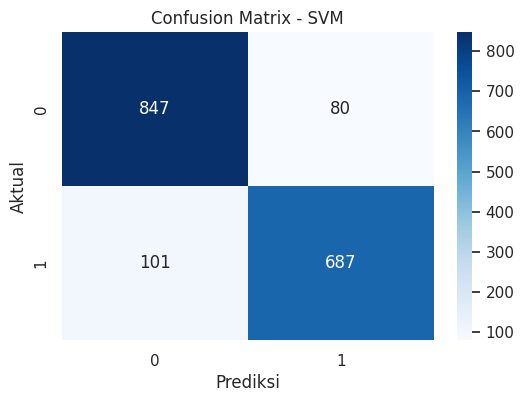

In [ ]:
# ==========================================
# MODEL SVM (SUPPORT VECTOR MACHINE)
# ==========================================

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Inisiasi Model SVM
print("Sedang melatih model SVM... (Mohon tunggu sebentar)")
svm_model = SVC(kernel='linear', random_state=42)

# 2. Training Model (X_train, y_train)
svm_model.fit(X_train, y_train)

# 3. Prediksi ke Data Test
y_pred_test_svm = svm_model.predict(X_test)

# 4. Evaluasi Hasil
print("\n=== HASIL EVALUASI MODEL SVM ===")
acc_svm = accuracy_score(y_test, y_pred_test_svm)
print(f"Akurasi SVM: {acc_svm:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_svm))

# 5. Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_test_svm), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## KNN (K=3)

Sedang mencari nilai K terbaik (1-20)...
Grafik Elbow Method ditampilkan. Pilih K dengan error terendah.


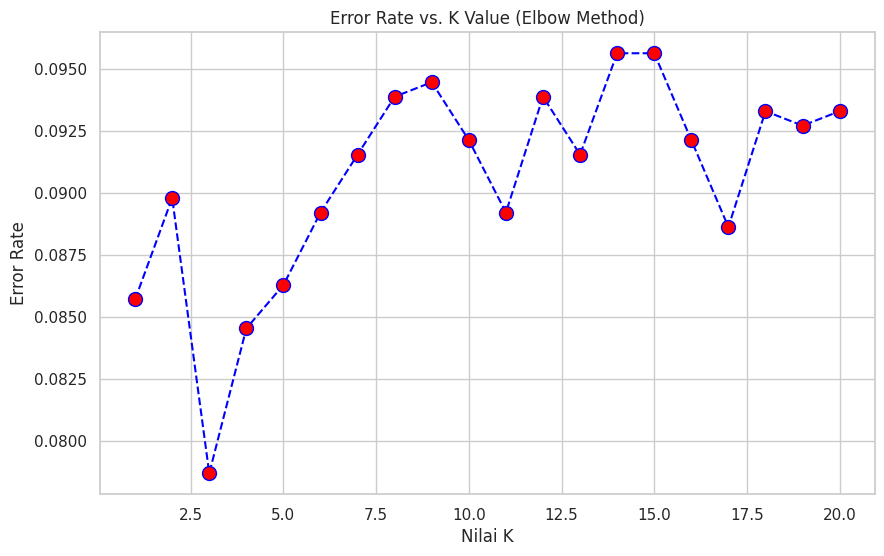


Melatih KNN dengan K=3...

=== HASIL EVALUASI MODEL KNN ===
Akurasi KNN: 92.13%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       927
           1       0.91      0.92      0.91       788

    accuracy                           0.92      1715
   macro avg       0.92      0.92      0.92      1715
weighted avg       0.92      0.92      0.92      1715



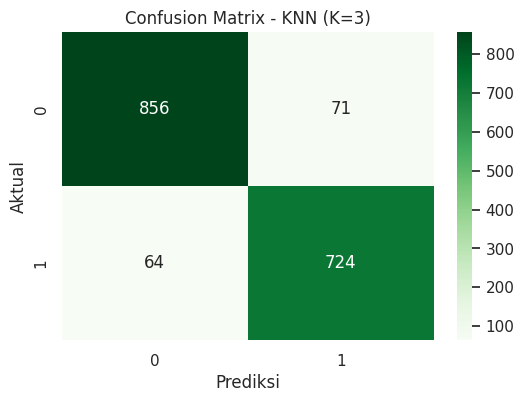

In [ ]:
# ==========================================
# KNN (K-NEAREST NEIGHBORS)
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# --- BAGIAN 1: MENCARI NILAI 'K' TERBAIK (ELBOW METHOD) 1-20 ---
error_rate = []

print("Sedang mencari nilai K terbaik (1-20)...")
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

# Plot Grafik Error Rate
plt.figure(figsize=(10,6))
plt.plot(range(1, 21), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Elbow Method)')
plt.xlabel('Nilai K')
plt.ylabel('Error Rate')
print("Grafik Elbow Method ditampilkan. Pilih K dengan error terendah.")
plt.show()

# --- BAGIAN 2: JALANKAN MODEL DENGAN K TERBAIK ---
k_terbaik = 3
print(f"\nMelatih KNN dengan K={k_terbaik}...")

knn_model = KNeighborsClassifier(n_neighbors=k_terbaik)
knn_model.fit(X_train, y_train)
y_pred_test_knn = knn_model.predict(X_test)

# --- BAGIAN 3: EVALUASI HASIL ---
print("\n=== HASIL EVALUASI MODEL KNN ===")
acc_knn = accuracy_score(y_test, y_pred_test_knn)
print(f"Akurasi KNN: {acc_knn:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_knn))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_test_knn), annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - KNN (K={k_terbaik})')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## Stacking Ensemble

### Perbandingan 9 Model

/tmp/ipython-input-2203584303.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')


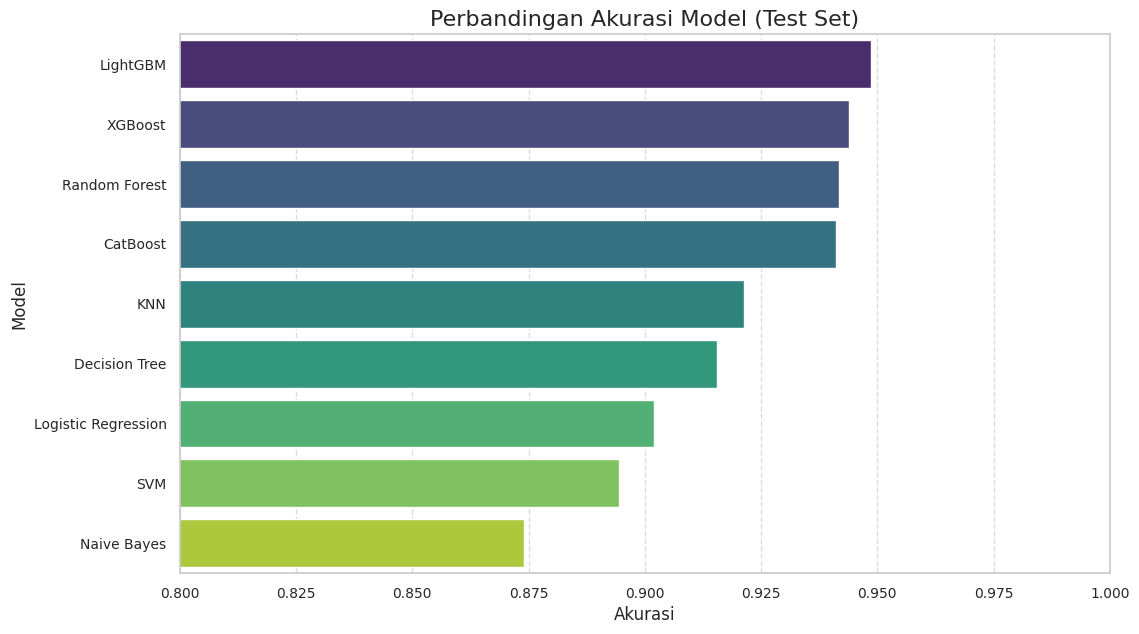

,Model,Accuracy
5,LightGBM,0.948688
2,XGBoost,0.944023
0,Random Forest,0.941691
3,CatBoost,0.941108
8,KNN,0.921283
1,Decision Tree,0.915452
6,Logistic Regression,0.902041
7,SVM,0.894461
4,Naive Bayes,0.874052


In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collect test accuracies for all models
model_accuracies = {
    "Random Forest": accuracy_score(y_test, y_pred_test_rf),
    "Decision Tree": acc_test_dt,
    "XGBoost": accuracy_score(y_test, y_pred_test_xgb),
    "CatBoost": accuracy_score(y_test, y_pred_test_cb),
    "Naive Bayes": accuracy_score(y_test, y_pred_test_nb),
    "LightGBM": accuracy_score(y_test, y_pred_test_lgbm),
    "Logistic Regression": acc_test_log,
    "SVM": acc_svm,
    "KNN": acc_knn
}

# Create a DataFrame for easy plotting
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])

# Sort by accuracy for better visualization
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Perbandingan Akurasi Model (Test Set)', fontsize=16)
plt.xlabel('Akurasi', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.8, 1.0) # Set x-axis limit to focus on accuracy range
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(accuracy_df)

/tmp/ipython-input-4207133301.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recall', y='Model', data=recall_df, palette='viridis')


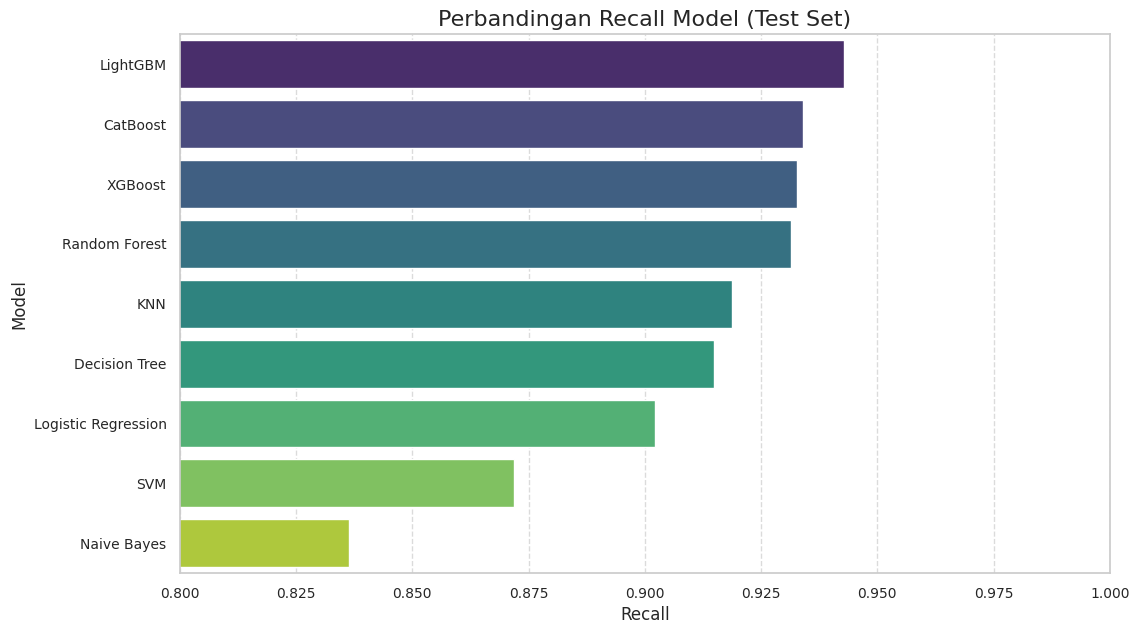

,Model,Recall
5,LightGBM,0.942893
3,CatBoost,0.934010
2,XGBoost,0.932741
0,Random Forest,0.931472
8,KNN,0.918782
1,Decision Tree,0.914975
6,Logistic Regression,0.902284
7,SVM,0.871827
4,Naive Bayes,0.836294


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collect test recall for all models
model_recalls = {
    "Random Forest": classification_report(y_test, y_pred_test_rf, output_dict=True)['1']['recall'],
    "Decision Tree": classification_report(y_test, y_pred_test_dt, output_dict=True)['1']['recall'],
    "XGBoost": classification_report(y_test, y_pred_test_xgb, output_dict=True)['1']['recall'],
    "CatBoost": classification_report(y_test, y_pred_test_cb, output_dict=True)['1']['recall'],
    "Naive Bayes": classification_report(y_test, y_pred_test_nb, output_dict=True)['1']['recall'],
    "LightGBM": classification_report(y_test, y_pred_test_lgbm, output_dict=True)['1']['recall'],
    "Logistic Regression": classification_report(y_test, y_pred_test_lr, output_dict=True)['1']['recall'],
    "SVM": classification_report(y_test, y_pred_test_svm, output_dict=True)['1']['recall'],
    "KNN": classification_report(y_test, y_pred_test_knn, output_dict=True)['1']['recall']
}

# Create a DataFrame for easy plotting
recall_df = pd.DataFrame(model_recalls.items(), columns=['Model', 'Recall'])

# Sort by recall for better visualization
recall_df = recall_df.sort_values(by='Recall', ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Recall', y='Model', data=recall_df, palette='viridis')
plt.title('Perbandingan Recall Model (Test Set)', fontsize=16)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.8, 1.0) # Set x-axis limit to focus on recall range
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(recall_df)

### Model Stacking (XGBoost, LightGBM, CatBoost)

Melatih Stacking Ensemble Model...

Akurasi Stacking Ensemble: 94.52%

Classification Report (Test Set Stacking Ensemble):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       927
           1       0.94      0.94      0.94       788

    accuracy                           0.95      1715
   macro avg       0.94      0.94      0.94      1715
weighted avg       0.95      0.95      0.95      1715



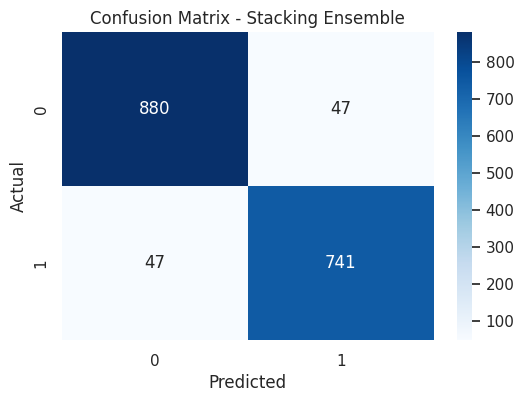

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define base estimators
estimators = [
    ('xgb', XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=-1, random_state=42)),
    ('cb', CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.1, loss_function='Logloss', random_state=42, verbose=0)) # Changed to CatBoost
]

# Define the final estimator (meta-learner)
final_estimator = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", class_weight="balanced", max_iter=1000, random_state=42)

# Create the StackingClassifier model
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5, # Number of cross-validation folds
    stack_method='auto', # Use best default method for base estimators
    n_jobs=-1, # Use all available cores
    verbose=1 # Display progress
)

print("Melatih Stacking Ensemble Model...")
# Train the stacking model
stacking_model.fit(X_train, y_train)

# Predict on the test set
y_pred_test_stack = stacking_model.predict(X_test)

# Evaluate the stacking model
acc_stack = accuracy_score(y_test, y_pred_test_stack)
print(f"\nAkurasi Stacking Ensemble: {acc_stack:.2%}")

print("\nClassification Report (Test Set Stacking Ensemble):")
print(classification_report(y_test, y_pred_test_stack))

# Plot Confusion Matrix
cm_stack = confusion_matrix(y_test, y_pred_test_stack)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Stacking Ensemble')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Perbandingan 10 Model

/tmp/ipython-input-1117157124.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recall', y='Model', data=recall_df, palette='viridis')


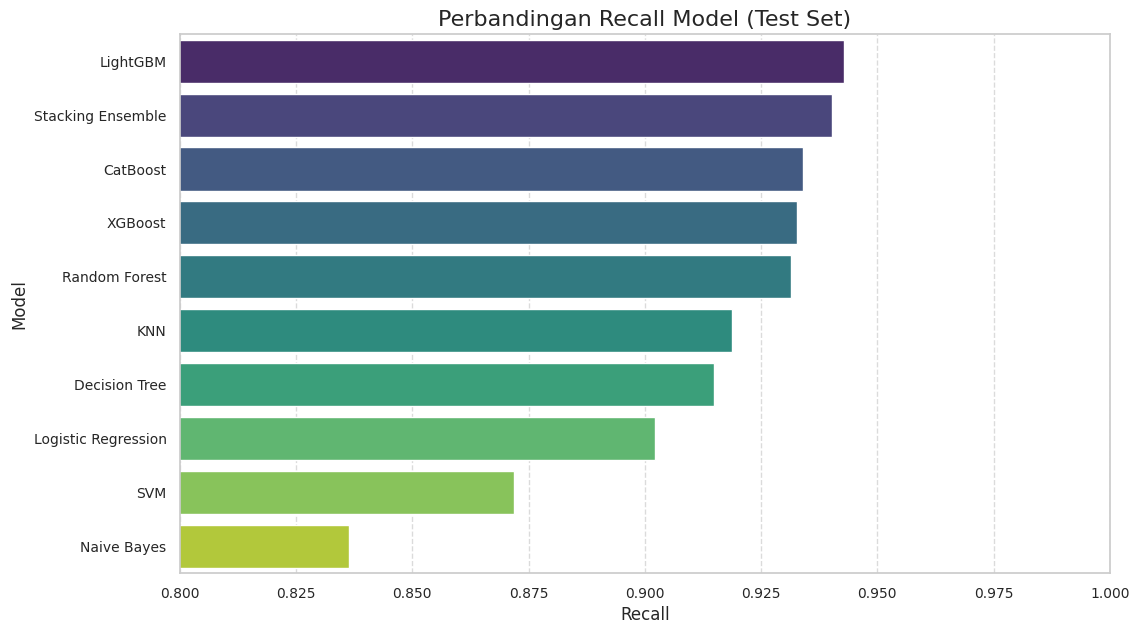

,Model,Recall
5,LightGBM,0.942893
9,Stacking Ensemble,0.940355
3,CatBoost,0.934010
2,XGBoost,0.932741
0,Random Forest,0.931472
8,KNN,0.918782
1,Decision Tree,0.914975
6,Logistic Regression,0.902284
7,SVM,0.871827
4,Naive Bayes,0.836294


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collect test recall for all models
model_recalls = {
    "Random Forest": classification_report(y_test, y_pred_test_rf, output_dict=True)['1']['recall'],
    "Decision Tree": classification_report(y_test, y_pred_test_dt, output_dict=True)['1']['recall'],
    "XGBoost": classification_report(y_test, y_pred_test_xgb, output_dict=True)['1']['recall'],
    "CatBoost": classification_report(y_test, y_pred_test_cb, output_dict=True)['1']['recall'],
    "Naive Bayes": classification_report(y_test, y_pred_test_nb, output_dict=True)['1']['recall'],
    "LightGBM": classification_report(y_test, y_pred_test_lgbm, output_dict=True)['1']['recall'],
    "Logistic Regression": classification_report(y_test, y_pred_test_lr, output_dict=True)['1']['recall'],
    "SVM": classification_report(y_test, y_pred_test_svm, output_dict=True)['1']['recall'],
    "KNN": classification_report(y_test, y_pred_test_knn, output_dict=True)['1']['recall'],
    "Stacking Ensemble": classification_report(y_test, y_pred_test_stack, output_dict=True)['1']['recall']
}

# Create a DataFrame for easy plotting
recall_df = pd.DataFrame(model_recalls.items(), columns=['Model', 'Recall'])

# Sort by recall for better visualization
recall_df = recall_df.sort_values(by='Recall', ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Recall', y='Model', data=recall_df, palette='viridis')
plt.title('Perbandingan Recall Model (Test Set)', fontsize=16)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.8, 1.0) # Set x-axis limit to focus on recall range
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(recall_df)

# Cross validation Before Tuning

## k-Fold CV

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

X_cv = X_train_val
y_cv = y_train_val

# Definisikan model-model yang mau di-CV
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(criterion="gini", random_state=42),
    "XGBoost": XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=500, depth=6, learning_rate=0.1, loss_function='Logloss', random_state=42, verbose=0),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=-1, random_state=42),
    "Logistic Regression": LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "SVM (Linear)": SVC(kernel='linear', random_state=42),
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "f1": "f1"
}

cv_results = []

print("=== Cross Validation (10-Fold) sebelum tuning ===\n")

for name, model in models.items():
    scores = cross_validate(
        model,
        X_cv, y_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy_mean": scores["test_accuracy"].mean(),
        "Accuracy_std": scores["test_accuracy"].std(),
        "Recall_mean": scores["test_recall"].mean(),
        "Recall_std": scores["test_recall"].std(),
        "F1_mean": scores["test_f1"].mean(),
        "F1_std": scores["test_f1"].std(),
    })

cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values(by="Recall_mean", ascending=False)

display(cv_df)

top_n = 3
top_models = cv_df.sort_values(by="Recall_mean", ascending=False).head(top_n)

print("=== REKOMENDASI MODEL TERBAIK UNTUK TUNING ===\n")
print(top_models[["Model", "Accuracy_mean", "Recall_mean", "F1_mean"]])

=== Cross Validation (10-Fold) sebelum tuning ===



,Model,Accuracy_mean,Accuracy_std,Recall_mean,Recall_std,F1_mean,F1_std
4,LightGBM,0.947812,0.005181,0.942869,0.013361,0.943159,0.005817
3,CatBoost,0.947400,0.005932,0.940406,0.015077,0.942589,0.006656
2,XGBoost,0.946472,0.006297,0.940401,0.013103,0.941654,0.006895
0,Random Forest,0.946165,0.007955,0.938832,0.014456,0.941239,0.008797
1,Decision Tree,0.925166,0.007578,0.929871,0.012016,0.919484,0.007890
7,KNN (k=3),0.928563,0.008236,0.922027,0.013322,0.922234,0.008867
5,Logistic Regression,0.904992,0.004862,0.899843,0.012192,0.896917,0.005365
6,SVM (Linear),0.893051,0.010139,0.870487,0.013732,0.882041,0.011250


=== REKOMENDASI MODEL TERBAIK UNTUK TUNING ===

      Model  Accuracy_mean  Recall_mean   F1_mean
4  LightGBM       0.947812     0.942869  0.943159
3  CatBoost       0.947400     0.940406  0.942589
2   XGBoost       0.946472     0.940401  0.941654


# Tuning Model Stacking Ensemble

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# 1. Data untuk tuning (CV)
# ==============================
# Sama seperti sebelumnya:
# X_train_val, y_train_val sudah kamu pakai sebagai X_cv, y_cv
X_tune = X_train_val
y_tune = y_train_val

# ==============================
# 2. Base model LightGBM
#    (disesuaikan dengan model awalmu)
# ==============================
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

# ==============================
# 3. Ruang hyperparameter
#    (di sekitar nilai awalmu)
# ==============================
param_dist_lgbm = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [-1, 3, 5, 7, 9],
    "num_leaves": [31, 63, 127],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.6, 0.8, 1.0],        # bagging_fraction
    "colsample_bytree": [0.6, 0.8, 1.0], # feature_fraction
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 0.1, 0.5, 1.0],
}

# ==============================
# 4. RandomizedSearchCV untuk LGBM
#    (pakai recall karena di CV kamu
#     model di-rank berdasarkan Recall_mean)
# ==============================
lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist_lgbm,
    n_iter=50,              # bisa dinaikkan kalau kuat komputasinya
    scoring="recall",       # bisa ganti "f1" / "roc_auc" sesuai kebutuhan
    cv=cv,                  # StratifiedKFold(10) dari kode sebelumnya
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("=== Mulai tuning LightGBM (RandomizedSearchCV) ===")
lgbm_search.fit(X_tune, y_tune)

print("\n===== HASIL TUNING LIGHTGBM =====")
print("Best params:", lgbm_search.best_params_)
print("Best CV recall:", lgbm_search.best_score_)

# Model terbaik hasil tuning
lgbm_model = lgbm_search.best_estimator_

# ==============================
# 5. Evaluasi dengan skema lama
#    (train / val / test)
# ==============================

# pakai model hasil tuning, tapi evaluasinya sama persis
# seperti kode awalmu
y_pred_train_lgbm = lgbm_model.predict(X_train)
y_pred_val_lgbm   = lgbm_model.predict(X_val)
y_pred_test_lgbm  = lgbm_model.predict(X_test)

print("\n=== REPORT TRAIN ===")
print(classification_report(y_train, y_pred_train_lgbm))

print("\n=== REPORT VAL ===")
print(classification_report(y_val, y_pred_val_lgbm))

print("\n=== REPORT TEST ===")
print(classification_report(y_test, y_pred_test_lgbm))
print("\nConfusion Matrix (TEST):")
print(confusion_matrix(y_test, y_pred_test_lgbm))

=== Mulai tuning LightGBM (RandomizedSearchCV) ===
Fitting 10 folds for each of 50 candidates, totalling 500 fits
[LightGBM] [Info] Number of positive: 4463, number of negative: 5252
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1033
[LightGBM] [Info] Number of data points in the train set: 9715, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.459393 -> initscore=-0.162788
[LightGBM] [Info] Start training from score -0.162788

===== HASIL TUNING LIGHTGBM =====
Best params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV recall: 0.9439878211494669

=== REPORT TRAIN ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      43

# Analisis Kesalahan

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# =====================================================
# 1. Model LightGBM (BEST PARAMS)
# =====================================================
lgbm_best = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0.0,
    reg_lambda=0.5,
    random_state=42
)

# =====================================================
# 2. Train model (train + validation)
# =====================================================
lgbm_best.fit(X_train_val, y_train_val)

# =====================================================
# 3. Prediksi
# =====================================================
y_pred_train = lgbm_best.predict(X_train)
y_pred_val   = lgbm_best.predict(X_val)
y_pred_test  = lgbm_best.predict(X_test)

# =====================================================
# 4. Classification report (Train / Val / Test)
# =====================================================
print("=== REPORT TRAIN ===")
print(classification_report(y_train, y_pred_train))

print("\n=== REPORT VALIDATION ===")
print(classification_report(y_val, y_pred_val))

print("\n=== REPORT TEST ===")
print(classification_report(y_test, y_pred_test))

# =====================================================
# 5. Ambil metrik khusus kelas 1 (PHISHING)
# =====================================================
report_test = classification_report(
    y_test,
    y_pred_test,
    output_dict=True
)

precision_1 = report_test["1"]["precision"]
recall_1    = report_test["1"]["recall"]
f1_1        = report_test["1"]["f1-score"]

print("\n=== METRIC KHUSUS KELAS 1 (PHISHING) — TEST SET ===")
print(f"Precision (1): {precision_1:.4f}")
print(f"Recall (1):    {recall_1:.4f}")
print(f"F1-Score (1):  {f1_1:.4f}")

# =====================================================
# 6. Confusion Matrix (TEST)
# =====================================================
cm_test = confusion_matrix(y_test, y_pred_test)

print("\nConfusion Matrix (TEST):")
print(cm_test)

[LightGBM] [Info] Number of positive: 4463, number of negative: 5252
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1033
[LightGBM] [Info] Number of data points in the train set: 9715, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.459393 -> initscore=-0.162788
[LightGBM] [Info] Start training from score -0.162788
=== REPORT TRAIN ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4328
           1       0.99      0.99      0.99      3677

    accuracy                           0.99      8005
   macro avg       0.99      0.99      0.99      8005
weighted avg       0.99      0.99      0.99      8005


=== REPORT VALIDATION ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       924
           1       0.99   

### SHAP

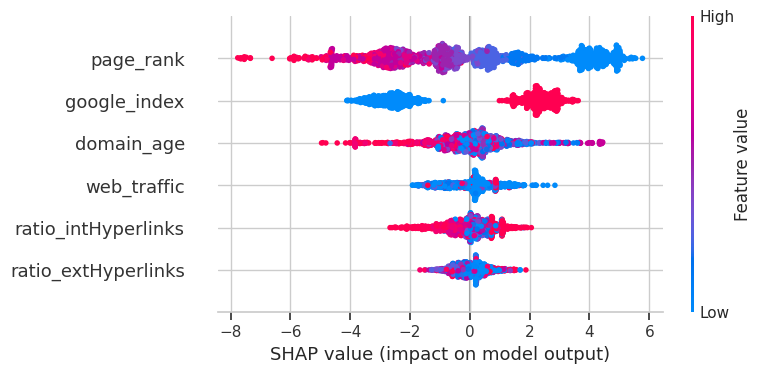

In [ ]:
import shap

# pakai model final kamu
explainer = shap.TreeExplainer(lgbm_best)

# hitung shap values
shap_values = explainer(X_test)

# summary plot
# kalau shap_values berbentuk list (per kelas), ambil kelas 1 (phishing)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

In [ ]:
import os
import numpy as np
import pandas as pd

output_dir = "ambiguitas_rows_lgbm"
os.makedirs(output_dir, exist_ok=True)

y_true_arr = np.array(y_test)
y_pred_arr = np.array(y_pred_test)

fp_idx = np.where((y_true_arr == 0) & (y_pred_arr == 1))[0]
fn_idx = np.where((y_true_arr == 1) & (y_pred_arr == 0))[0]
correct_idx = np.where(y_true_arr == y_pred_arr)[0]

features = [
    "domain_age",
    "web_traffic",
    "google_index",
    "page_rank",
    "ratio_extHyperlinks",
    "ratio_intHyperlinks"
]

def feature_summary(df, feature):
    # ringkasan statistik yang umum dipakai
    return pd.Series({
        "count": df[feature].shape[0],
        "missing": df[feature].isna().sum(),
        "mean": df[feature].mean(),
        "median": df[feature].median(),
        "std": df[feature].std(),
        "min": df[feature].min(),
        "q25": df[feature].quantile(0.25),
        "q75": df[feature].quantile(0.75),
        "max": df[feature].max(),
    })

all_summaries = []

for feature in features:
    if feature not in X_test.columns:
        print(f"Warning: Kolom '{feature}' tidak ditemukan di X_test. Skip.")
        continue

    df_fp = X_test.iloc[fp_idx][[feature]].copy()
    df_fn = X_test.iloc[fn_idx][[feature]].copy()
    df_corr = X_test.iloc[correct_idx][[feature]].copy()

    # --- SUMMARY per grup ---
    s_fp = feature_summary(df_fp, feature)
    s_fn = feature_summary(df_fn, feature)
    s_corr = feature_summary(df_corr, feature)

    summary_df = pd.DataFrame([s_fp, s_fn, s_corr], index=["FP", "FN", "Correct"])
    summary_df.insert(0, "feature", feature)
    summary_path = os.path.join(output_dir, f"summary_{feature}.csv")
    summary_df.to_csv(summary_path)
    print(f"Saved: {summary_path}")

    # simpan juga untuk summary gabungan
    tmp = summary_df.reset_index(names="group")
    all_summaries.append(tmp)

# --- SUMMARY gabungan semua fitur ---
if all_summaries:
    df_all_summary = pd.concat(all_summaries, ignore_index=True)
    df_all_summary.to_csv(os.path.join(output_dir, "summary_all_features.csv"), index=False)
    print("Saved: ambiguitas_rows_lgbm/summary_all_features.csv")

print("\nTotal kasus:")
print("FP:", len(fp_idx), "FN:", len(fn_idx), "Correct:", len(correct_idx))


Saved: ambiguitas_rows_lgbm/summary_domain_age.csv
Saved: ambiguitas_rows_lgbm/summary_web_traffic.csv
Saved: ambiguitas_rows_lgbm/summary_google_index.csv
Saved: ambiguitas_rows_lgbm/summary_page_rank.csv
Saved: ambiguitas_rows_lgbm/summary_ratio_extHyperlinks.csv
Saved: ambiguitas_rows_lgbm/summary_ratio_intHyperlinks.csv
Saved: ambiguitas_rows_lgbm/summary_all_features.csv

Total kasus:
FP: 41 FN: 43 Correct: 1631
